## AI 305 Project 
## NBA Player Performance Analysis 
### Group Members:
### •	Juri Almarwani 4410761
### •	Nejoud Fahad Alharbi 4410570
### •	Shahad Tahir 4410656
 

In [31]:
# Our project applies supervised and unsupervised learning techniques to analyze player performance, identify player archetypes, and predict game outcomes

In [32]:
# This project applies supervised and unsupervised learning to NBA player statistics from the 2024/2025 season.
# Task File Objective
# Core 1: Regression Task 1.ipynb  Predict Player Points (PTS).
# Core 2: Clustering Task 2.ipynb Identify Player Style Archetypes.
# Core 3: Classification Task 3.ipynb Predict Game Outcome (Win/Loss).
# Bonus Bouns.ipynbAnalyze Temporal Performance Trends.

In [33]:
# Ensure the following Python libraries are installed before running the notebooks:
# pip install pandas numpy scikit-learn matplotlib seaborn

In [34]:
# The required dataset, database_24_25.csv, must be placed in the same directory as the notebooks.

In [35]:
# Run the Jupyter Notebook files sequentially from top to bottom.

# Run Task 1.ipynb Regression (PTS Prediction).
# Run Task 2.ipynb Clustering (Player Archetypes).
# Run Task 3.ipynb Classification (Win/Loss Prediction).
# Run Bouns.ipynb Temporal Performance Analysis.

In [36]:
# Task 1 : Model Comparison : Summary table of RMSE and R² Score.

In [37]:
# Task 2 : Player Grouping : PCA Visualization plot

In [38]:
# Task 3 : Win/Loss Prediction : ROC-AUC plot and F1-Score summary table.

In [39]:
# Bonus	: Performance Trends : Line plot showing 5-Game Rolling Averages.

# Task one 

In [40]:
# AI305 - NBA Project - Task 1 (Regression)
# Target: PTS
# Models: Linear Regression, Random Forest, SVR



import pandas as pd # Library for loading and working with datasets
import numpy as np  # Numerical operations used for math, arrays


from sklearn.model_selection import train_test_split  # Splits data into train test sets
from sklearn.preprocessing import StandardScaler     # Standardizes features (important for SVR)
from sklearn.linear_model import LinearRegression    # Linear Regression model
from sklearn.ensemble import RandomForestRegressor   # Random Forest model
from sklearn.svm import SVR # Support Vector Regression model
from sklearn.metrics import mean_squared_error, r2_score # Evaluation metrics: RMSE and R²

In [41]:
file_path = r"C:\\Users\\Juri Almarwani\\Desktop\\AI305 Project\\database_24_25.csv"   # Full path to dataset
df = pd.read_csv(file_path)



print("Original shape:", df.shape) # Print number of rows and columns
print(df.head())  # Preview first 5 rows to ensure dataset loaded correctly
# Preiew frst 5 rows to ensure dataset loaded corectly


Original shape: (16512, 25)
          Player   Tm  Opp Res     MP  FG  FGA    FG%  3P  3PA  ...  DRB  TRB  \
0   Jayson Tatum  BOS  NYK   W  30.30  14   18  0.778   8   11  ...    4    4   
1  Anthony Davis  LAL  MIN   W  37.58  11   23  0.478   1    3  ...   13   16   
2  Derrick White  BOS  NYK   W  26.63   8   13  0.615   6   10  ...    3    3   
3   Jrue Holiday  BOS  NYK   W  30.52   7    9  0.778   4    6  ...    2    4   
4  Miles McBride  NYK  BOS   L  25.85   8   10  0.800   4    5  ...    0    0   

   AST  STL  BLK  TOV  PF  PTS  GmSc        Data  
0   10    1    1    1   1   37  38.1  2024-10-22  
1    4    1    3    1   1   36  34.0  2024-10-22  
2    4    1    0    0   1   24  22.4  2024-10-22  
3    4    1    0    0   2   18  19.5  2024-10-22  
4    2    0    0    1   1   22  17.8  2024-10-22  

[5 rows x 25 columns]


In [42]:
# BASIC CLEANING 
# Remove rows where PTS is missing, since it is our target
df = df.dropna(subset=["PTS"])      


# If dataset contains MP (minutes played), remove games where MP = 0 (player did not play)
if "MP" in df.columns:
    df = df[df["MP"] > 0]

    

# Fill missing shooting percentages with 0 (because missing usually means no attempts)
for col in ["FG%", "3P%", "FT%"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

    

# Remove infinite values and remaining missing values to avoid model errors
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print("After cleaning:", df.shape) # Show shape after cleaning  


After cleaning: (16508, 25)


In [43]:
#  3. FEATURE ENGINEERING 

# True Shooting Percentage (TS%) 
# Formula: TS% = PTS / (2 * (FGA + 0.44*FTA))
if all(c in df.columns for c in ["PTS", "FGA", "FTA"]):
    df["TS%"] = df["PTS"] / (2 * (df["FGA"] + 0.44 * df["FTA"]).replace(0, np.nan))
else:
    df["TS%"] = np.nan   # If columns missing, create TS% as NaN





#  Assist-to-Turnover Ratio (A_TOV) 
# Formula: AST / (TOV + 1) → add 1 to avoid division by zero
if all(c in df.columns for c in ["AST", "TOV"]):
    df["A_TOV"] = df["AST"] / (df["TOV"] + 1)
else:
    df["A_TOV"] = np.nan





#  Defensive Impact Score 
# Formula: DIS = 2*STL + BLK + DRB
for col in ["STL", "BLK", "DRB"]:
    if col not in df.columns:
        df[col] = 0          # If missing, replace with 0 to avoid errors
df["DIS"] = (df["STL"] * 2) + df["BLK"] + df["DRB"]

# Clean dataset again from any infinities after calculations
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print("After feature engineering:", df.shape)
    

After feature engineering: (15680, 28)


In [44]:

# 4. PREPARE DATA FOR REGRESSION 

# List of features used to predict PTS
feature_cols = [
    "MP", "FGA", "3PA", "FTA",
    "FG%", "3P%", "FT%",
    "AST", "TRB", "STL", "BLK", "TOV",
    "TS%", "A_TOV", "DIS"
]

# Keep only columns that actually exist in dataset
feature_cols = [c for c in feature_cols if c in df.columns]

# X = input features, y = target variable (PTS)
X = df[feature_cols]
y = df["PTS"]

print("\nFeatures used:")
print(feature_cols)



Features used:
['MP', 'FGA', '3PA', 'FTA', 'FG%', '3P%', 'FT%', 'AST', 'TRB', 'STL', 'BLK', 'TOV', 'TS%', 'A_TOV', 'DIS']


In [45]:
# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features → important for SVR to work correctly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)    # Fit on training data only
X_test_scaled = scaler.transform(X_test)          # Transform test data with same scaler


In [46]:
# --- Model 1: Linear Regression ---
lr = LinearRegression()                  # Create model
lr.fit(X_train_scaled, y_train)          # Train model
y_pred_lr = lr.predict(X_test_scaled)    # Predict PTS on test data


In [47]:
# Model 2: Random Forest Regressor 
rf = RandomForestRegressor(n_estimators=300, random_state=42)  # Create forest with 300 trees
rf.fit(X_train, y_train)                                       # Train (tree models do NOT need scaling)
y_pred_rf = rf.predict(X_test)                                 # Predict PTS


In [49]:
#  Model 3: Support Vector Regression (SVR)
svr = SVR(kernel="rbf", C=10, gamma="scale")  # Create SVR with RBF kernel
svr.fit(X_train_scaled, y_train)              # Train on scaled data
y_pred_svr = svr.predict(X_test_scaled)       # Predict PTS


In [50]:
def eval_regression(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))   # RMSE calculation
    r2   = r2_score(y_true, y_pred)                      # R² calculation

    print(f"{name:20s} -> RMSE: {rmse:.3f},  R²: {r2:.3f}")

    return rmse, r2 

In [51]:

print("\n=== Task 1: Regression Results (Predict PTS) ===")
res_lr  = eval_regression("Linear Regression",    y_test, y_pred_lr)
res_rf  = eval_regression("Random Forest",        y_test, y_pred_rf)
res_svr = eval_regression("SVR",                  y_test, y_pred_svr)





# Summary table for report
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "SVR"],
    "RMSE":  [res_lr[0], res_rf[0], res_svr[0]],
    "R2":    [res_lr[1], res_rf[1], res_svr[1]],
})

print("\nSummary Table:")
print(results_df)


=== Task 1: Regression Results (Predict PTS) ===
Linear Regression    -> RMSE: 2.307,  R²: 0.929
Random Forest        -> RMSE: 0.418,  R²: 0.998
SVR                  -> RMSE: 0.544,  R²: 0.996

Summary Table:
               Model      RMSE        R2
0  Linear Regression  2.306528  0.928816
1      Random Forest  0.418473  0.997657
2                SVR  0.543568  0.996047


## Task two 

In [52]:
# Import libraries for data handling and plotting
import pandas as pd          # For loading and manipulating tabular data
import numpy as np           # For numerical operations
import matplotlib.pyplot as plt  # For creating plots
import seaborn as sns        # For prettier statistical visualizations

# Import sklearn tools for preprocessing, clustering, evaluation, and dimensionality reduction
from sklearn.preprocessing import StandardScaler      # For feature scaling (normalization)
from sklearn.cluster import KMeans                    # K-Means clustering algorithm
from sklearn.mixture import GaussianMixture           # Gaussian Mixture Models (GMM) clustering
from sklearn.metrics import silhouette_score          # To evaluate cluster quality
from sklearn.decomposition import PCA                 # Principal Component Analysis for visualization

In [53]:
# Load the per-game player statistics dataset from a CSV file
# Change the filename if your file is named differently
#df = pd.read_csv("C:\\Users\\HP\\Desktop\\dataset\\database_24_25.csv")

# Show the first 5 rows to confirm it loaded correctly
df.head()

,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,...,STL,BLK,TOV,PF,PTS,GmSc,Data,TS%,A_TOV,DIS
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,...,1,1,1,1,37,38.1,2024-10-22,0.979873,5.0,7
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,...,1,3,1,1,36,34.0,2024-10-22,0.608108,2.0,18
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,...,1,0,0,1,24,22.4,2024-10-22,0.864553,4.0,5
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,...,1,0,0,2,18,19.5,2024-10-22,1.000000,4.0,4
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,...,0,0,1,1,22,17.8,2024-10-22,0.971731,1.0,0


In [54]:
df.shape
# Show the shape of the dataset: (number of rows, number of columns)

(15680, 28)

In [55]:
df.columns
# Look at all column names to know what features are available

Index(['Player', 'Tm', 'Opp', 'Res', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA',
       '3P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PTS', 'GmSc', 'Data', 'TS%', 'A_TOV', 'DIS'],
      dtype='object')

In [56]:
# Start with a base list of features that describe player style
# These are core box score stats: scoring, playmaking, rebounding, defense
cluster_features = ["PTS", "AST", "TRB", "STL", "BLK"]

In [57]:
# If shooting percentage columns exist in the dataset, we include them too
# This makes the clusters more about efficiency and style, not just volume
if "FG%" in df.columns:
    cluster_features.append("FG%")   # Field goal percentage

if "3P%" in df.columns:
    cluster_features.append("3P%")   # Three-point percentage

if "FT%" in df.columns:
    cluster_features.append("FT%")   # Free-throw percentage

In [58]:
# Show the final list of features that will be used for clustering
cluster_features

['PTS', 'AST', 'TRB', 'STL', 'BLK', 'FG%', '3P%', 'FT%']

In [59]:
# Group the dataset by player name
# For each player, compute the mean of the selected stats across all their games
player_avg = df.groupby("Player")[cluster_features].mean().reset_index()

In [60]:
# Show the first few rows of the per-player averages dataset
player_avg.head()

,Player,PTS,AST,TRB,STL,BLK,FG%,3P%,FT%
0,A.J. Green,7.837209,1.279070,2.302326,0.534884,0.116279,0.436372,0.404465,0.143419
1,A.J. Lawson,2.750000,0.000000,0.750000,0.000000,0.000000,0.666750,0.500000,0.125000
2,AJ Johnson,2.750000,1.250000,1.125000,0.125000,0.000000,0.291750,0.187500,0.062500
3,Aaron Gordon,12.333333,3.066667,4.733333,0.466667,0.266667,0.510900,0.401000,0.630700
4,Aaron Holiday,4.342857,1.200000,0.971429,0.314286,0.114286,0.355429,0.283714,0.228571


In [61]:
# Show how many players are in the dataset and how many features we kept
player_avg.shape

(556, 9)

In [62]:
# Extract the feature values from the player_avg DataFrame as a NumPy array
# This will be the input to our clustering algorithms
X = player_avg[cluster_features].values

In [63]:
# Create a StandardScaler object to normalize features
# Scaling helps clustering algorithms treat all features fairly
scaler = StandardScaler()

In [64]:
# Fit the scaler on the data and transform it
# Each feature will have mean 0 and standard deviation 1
X_scaled = scaler.fit_transform(X)

In [65]:
# Show the first 5 rows of the scaled feature matrix
X_scaled[:5]

array([[-0.19052475, -0.43194298, -0.54656057, -0.34778138, -0.69961563,
         0.0315615 ,  1.07192758, -1.0250887 ],
       [-0.95913301, -1.12309901, -1.17314954, -1.52495504, -0.96970882,
         1.88057876,  1.7465053 , -1.10424742],
       [-0.95913301, -0.44765107, -1.02178254, -1.24985467, -0.96970882,
        -1.12917805, -0.46007651, -1.37285737],
       [ 0.48877856,  0.53399992,  0.43470436, -0.49791367, -0.35029511,
         0.62972383,  1.04746018,  1.06912941],
       [-0.71847392, -0.47466899, -1.08377093, -0.83327412, -0.7042458 ,
        -0.61809268,  0.21929851, -0.65912236]])

In [66]:
# Create empty lists to store inertia values (for the Elbow method)
# and silhouette scores for different k values
inertias = []
silhouette_scores = []

In [67]:
# Define the range of k (number of clusters) to test
k_values = range(2, 11)   # We will test k = 2, 3, ..., 10

In [68]:
import warnings 
warnings.filterwarnings('ignore')

In [69]:
inertias = []
silhouette_scores = []

In [70]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"   # Fix Windows wmic bug

# Loop over each k and fit K-Means, then record inertia and silhouette score
for k in k_values:
    # Create a K-Means model with k clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Fit the model and get the cluster labels for each player
    labels = kmeans.fit_predict(X_scaled)

    # Inertia measures how compact the clusters are (lower is better)
    inertias.append(kmeans.inertia_)

    # Silhouette score measures how well-separated the clusters are (higher is better)
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)

    # Print metrics for each k to help decide optimal number of clusters
    print("k =", k,
          "Inertia =", kmeans.inertia_,
          "Silhouette =", sil_score)




k = 2 Inertia = 3018.1938707719 Silhouette = 0.3012145037051251
k = 3 Inertia = 2576.318170061743 Silhouette = 0.21213883020502844
k = 4 Inertia = 2176.6448573949247 Silhouette = 0.23552960084912145
k = 5 Inertia = 1947.5570646239532 Silhouette = 0.21043121599676595
k = 6 Inertia = 1775.2721948487565 Silhouette = 0.21513165448213287
k = 7 Inertia = 1684.187235370714 Silhouette = 0.190819578246376
k = 8 Inertia = 1584.1871796636556 Silhouette = 0.18866392305744314
k = 9 Inertia = 1500.8271718744338 Silhouette = 0.17942017172375144
k = 10 Inertia = 1419.0648091697865 Silhouette = 0.18530903054147374


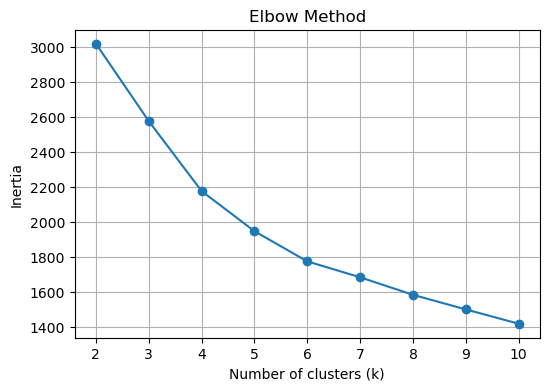

In [71]:
plt.figure(figsize=(6,4))
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


In [72]:
# Set the chosen number of clusters based on the previous analysis
optimal_k = 4   # Change this if your analysis suggests a different k

In [73]:
# Create a K-Means model with the chosen number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

In [74]:
# Fit the model and assign a cluster label to each player
kmeans_labels = kmeans.fit_predict(X_scaled)

In [75]:
# Add a new column to player_avg containing the K-Means cluster for each player
player_avg["KMeans_Cluster"] = kmeans_labels

In [76]:
# Show the first few players with their cluster labels
player_avg[["Player", "KMeans_Cluster"]].head()

,Player,KMeans_Cluster
0,A.J. Green,2
1,A.J. Lawson,3
2,AJ Johnson,3
3,Aaron Gordon,2
4,Aaron Holiday,3


In [77]:
# Compute the average stats per K-Means cluster
# This helps interpret what each cluster represents (e.g., scorers, playmakers)
player_avg.groupby("KMeans_Cluster")[cluster_features].mean()

,PTS,AST,TRB,STL,BLK,FG%,3P%,FT%
KMeans_Cluster,,,,,,,,
0,8.805593,1.662000,6.872496,0.640038,1.113656,0.575813,0.087967,0.442861
1,20.374351,4.938632,5.888945,1.161458,0.587452,0.465760,0.345427,0.709471
2,8.942285,2.003626,3.387717,0.808433,0.360993,0.441598,0.325717,0.371496
3,3.115499,0.726250,1.630188,0.301519,0.151363,0.351812,0.164622,0.191425


In [78]:
# Create a Gaussian Mixture Model with the same number of components as clusters
gmm = GaussianMixture(n_components=optimal_k, random_state=42)

In [79]:
# Fit the GMM and get the cluster labels
gmm_labels = gmm.fit_predict(X_scaled)

In [80]:
# Add a new column with GMM cluster labels
player_avg["GMM_Cluster"] = gmm_labels

In [81]:
# Show example players and their GMM cluster labels
player_avg[["Player", "GMM_Cluster"]].head()

,Player,GMM_Cluster
0,A.J. Green,0
1,A.J. Lawson,3
2,AJ Johnson,3
3,Aaron Gordon,0
4,Aaron Holiday,3


In [82]:
# Compute average stats per GMM cluster for interpretation
player_avg.groupby("GMM_Cluster")[cluster_features].mean()

,PTS,AST,TRB,STL,BLK,FG%,3P%,FT%
GMM_Cluster,,,,,,,,
0,8.505722,2.050966,3.250077,0.813441,0.324937,0.426162,0.313772,0.344785
1,19.229756,4.472327,5.746225,1.080612,0.574774,0.461464,0.343328,0.679634
2,7.731771,1.361285,5.916467,0.592323,0.995379,0.562553,0.090870,0.397799
3,3.031650,0.695066,1.515144,0.300606,0.134589,0.354779,0.186863,0.201388


In [83]:
# Create a PCA object to reduce dimensions to 2 components
pca = PCA(n_components=2, random_state=42)

In [84]:
# Fit PCA on the scaled data and transform it
# Each player is now represented by two PCA coordinates (PC1 and PC2)
pca_components = pca.fit_transform(X_scaled)

In [85]:
# Add the PCA coordinates to player_avg for plotting
player_avg["PC1"] = pca_components[:, 0]
player_avg["PC2"] = pca_components[:, 1]

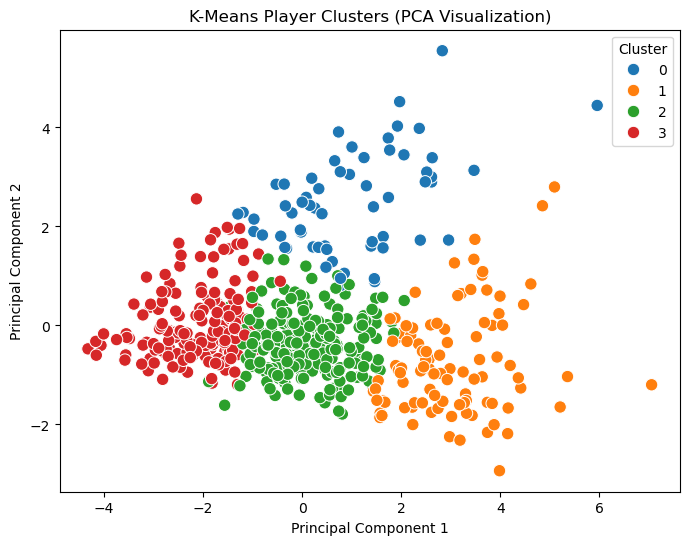

In [86]:
# Create a scatter plot of the players in PCA space colored by K-Means cluster
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=player_avg,
    x="PC1",
    y="PC2",
    hue="KMeans_Cluster",
    palette="tab10",
    s=80
)
plt.title("K-Means Player Clusters (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

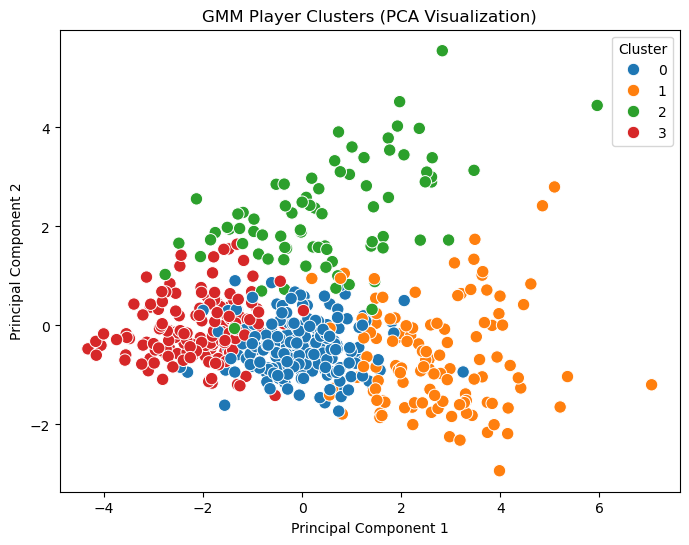

In [87]:
# Create a scatter plot of the players in PCA space colored by GMM cluster
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=player_avg,
    x="PC1",
    y="PC2",
    hue="GMM_Cluster",
    palette="tab10",
    s=80
)
plt.title("GMM Player Clusters (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [88]:
# Save the final per-player dataset with clusters and PCA coordinates
player_avg.to_csv("Task2_PlayerClusters.csv", index=False)

In [89]:
# Confirm that the file has been saved
print("Saved clustered player data to Task2_PlayerClusters.csv")

Saved clustered player data to Task2_PlayerClusters.csv


## Task three

In [90]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

In [91]:
 #bdf = pd.read_csv(r"C:\Users\HP\Desktop\dataset\database_24_25.csv")
df.head()

,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,...,STL,BLK,TOV,PF,PTS,GmSc,Data,TS%,A_TOV,DIS
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,...,1,1,1,1,37,38.1,2024-10-22,0.979873,5.0,7
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,...,1,3,1,1,36,34.0,2024-10-22,0.608108,2.0,18
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,...,1,0,0,1,24,22.4,2024-10-22,0.864553,4.0,5
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,...,1,0,0,2,18,19.5,2024-10-22,1.000000,4.0,4
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,...,0,0,1,1,22,17.8,2024-10-22,0.971731,1.0,0


In [92]:
# True Shooting Percentage (TS) - scoring efficiency
df["TS"] = df["PTS"] / (2 * (df["FGA"] + 0.44 * df["FTA"]))
df["TS"] = df["TS"].replace([np.inf, -np.inf], np.nan).fillna(0)

# Assist-to-Turnover ratio - playmaking efficiency
df["AST_TOV"] = df["AST"] / (df["TOV"] + 1)  # +1 to avoid division by zero
df["AST_TOV"] = df["AST_TOV"].replace([np.inf, -np.inf], np.nan).fillna(0)

# Defensive impact score - defensive contribution
df["DEF_IMPACT"] = (df["STL"] * 2) + df["BLK"] + df["DRB"]

In [93]:
# Columns that uniquely identify a team in a specific game
group_cols = ["Tm", "Opp", "Data", "Res"]

In [94]:
# Define how to aggregate stats for each team-game
# We sum counting stats and take the mean of efficiency stats
agg_dict = {
    "MP": "sum",
    "PTS": "sum",
    "AST": "sum",
    "TRB": "sum",
    "STL": "sum",
    "BLK": "sum",
    "TOV": "sum",
    "ORB": "sum",
    "DRB": "sum",
    "PF": "sum",
    "FG": "sum",
    "FGA": "sum",
    "3P": "sum",
    "3PA": "sum",
    "FT": "sum",
    "FTA": "sum",
    "GmSc": "sum",
    "TS": "mean",
    "AST_TOV": "mean",
    "DEF_IMPACT": "sum"
}

In [95]:
# Group by team-game and aggregate using the dictionary above
team_games = df.groupby(group_cols).agg(agg_dict).reset_index()

In [96]:
team_games.head()

,Tm,Opp,Data,Res,MP,PTS,AST,TRB,STL,BLK,...,FG,FGA,3P,3PA,FT,FTA,GmSc,TS,AST_TOV,DEF_IMPACT
0,ATL,BOS,2024-11-04,L,239.99,93,23,43,9,3,...,37,89,6,31,13,16,63.4,0.444775,0.764069,56
1,ATL,BOS,2024-11-12,W,239.99,117,35,44,16,2,...,50,99,10,32,7,13,105.2,0.590916,1.259259,59
2,ATL,BOS,2025-01-18,W,265.00,119,27,55,9,10,...,44,93,9,37,22,28,101.9,0.531180,1.046296,70
3,ATL,BRK,2024-10-23,W,239.98,120,25,45,12,9,...,39,80,9,28,33,46,104.5,0.582027,1.007937,66
4,ATL,CHI,2024-11-09,L,240.01,113,31,39,8,5,...,41,89,9,29,22,30,92.2,0.514993,1.003571,50


In [97]:
# Field goal percentage for the team
team_games["FG_PCT"] = team_games["FG"] / team_games["FGA"].replace(0, np.nan)

# 3-point percentage
team_games["TP_PCT"] = team_games["3P"] / team_games["3PA"].replace(0, np.nan)

# Free throw percentage
team_games["FT_PCT"] = team_games["FT"] / team_games["FTA"].replace(0, np.nan)

# Replace NaNs (from zero attempts) with 0
team_games[["FG_PCT", "TP_PCT", "FT_PCT"]] = team_games[["FG_PCT", "TP_PCT", "FT_PCT"]].fillna(0)

In [98]:
team_games.head()

,Tm,Opp,Data,Res,MP,PTS,AST,TRB,STL,BLK,...,3PA,FT,FTA,GmSc,TS,AST_TOV,DEF_IMPACT,FG_PCT,TP_PCT,FT_PCT
0,ATL,BOS,2024-11-04,L,239.99,93,23,43,9,3,...,31,13,16,63.4,0.444775,0.764069,56,0.415730,0.193548,0.812500
1,ATL,BOS,2024-11-12,W,239.99,117,35,44,16,2,...,32,7,13,105.2,0.590916,1.259259,59,0.505051,0.312500,0.538462
2,ATL,BOS,2025-01-18,W,265.00,119,27,55,9,10,...,37,22,28,101.9,0.531180,1.046296,70,0.473118,0.243243,0.785714
3,ATL,BRK,2024-10-23,W,239.98,120,25,45,12,9,...,28,33,46,104.5,0.582027,1.007937,66,0.487500,0.321429,0.717391
4,ATL,CHI,2024-11-09,L,240.01,113,31,39,8,5,...,29,22,30,92.2,0.514993,1.003571,50,0.460674,0.310345,0.733333


In [99]:
# Map 'W' -> 1 (win), 'L' -> 0 (loss)
team_games["win"] = team_games["Res"].map({"W": 1, "L": 0})

In [100]:
# Check distribution of wins vs losses
team_games["win"].value_counts(), team_games["win"].value_counts(normalize=True)

(win
 0    767
 1    767
 Name: count, dtype: int64,
 win
 0    0.5
 1    0.5
 Name: proportion, dtype: float64)

In [101]:
drop_cols = ["Tm", "Opp", "Data", "Res", "win"]  # to remove from features

In [102]:
X = team_games.drop(columns=drop_cols)
y = team_games["win"]

In [103]:
X.head()

,MP,PTS,AST,TRB,STL,BLK,TOV,ORB,DRB,PF,...,3PA,FT,FTA,GmSc,TS,AST_TOV,DEF_IMPACT,FG_PCT,TP_PCT,FT_PCT
0,239.99,93,23,43,9,3,19,8,35,13,...,31,13,16,63.4,0.444775,0.764069,56,0.415730,0.193548,0.812500
1,239.99,117,35,44,16,2,16,19,25,17,...,32,7,13,105.2,0.590916,1.259259,59,0.505051,0.312500,0.538462
2,265.00,119,27,55,9,10,17,13,42,17,...,37,22,28,101.9,0.531180,1.046296,70,0.473118,0.243243,0.785714
3,239.98,120,25,45,12,9,16,12,33,20,...,28,33,46,104.5,0.582027,1.007937,66,0.487500,0.321429,0.717391
4,240.01,113,31,39,8,5,13,10,29,19,...,29,22,30,92.2,0.514993,1.003571,50,0.460674,0.310345,0.733333


In [104]:
X.shape, y.shape

((1534, 23), (1534,))

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keep same class proportion in train & test
)

In [106]:
# 1. Set Up Pipelines (Continuation of previous notebook)
scaler = StandardScaler()

# Pipeline for models that benefit from scaling
lr_pipe = Pipeline([('scaler', scaler), ('lr', LogisticRegression(random_state=42, max_iter=1000))])
svc_pipe = Pipeline([('scaler', scaler), ('svc', SVC(random_state=42, probability=True))])

# Random Forest Pipeline
rf_pipe = Pipeline([('scaler', scaler), ('rf', RandomForestClassifier(random_state=42))]) 

models = {
    'Logistic Regression': lr_pipe,
    'Random Forest': rf_pipe,
    'SVC': svc_pipe
}

In [107]:
# 2. Hyperparameter Tuning using GridSearchCV on Random Forest
param_grid_rf = {
    'rf__n_estimators': [100, 200, 300],  # Number of trees
    'rf__max_depth': [5, 10, None],       # Maximum depth of the tree
    'rf__min_samples_split': [2, 5]       # Minimum number of samples required to split a node
}

# Use the Random Forest pipeline for tuning, scoring by F1-score
grid_search_rf = GridSearchCV(
    rf_pipe, 
    param_grid_rf, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1,
    verbose=1
)

print("Starting Grid Search for Random Forest...")
grid_search_rf.fit(X_train, y_train)

# Update the models dictionary with the best found Random Forest model
best_rf = grid_search_rf.best_estimator_
models['Random Forest (Tuned)'] = best_rf

print("Best RF Parameters:", grid_search_rf.best_params_)
print("Best RF F1 Score (CV):", grid_search_rf.best_score_)

Starting Grid Search for Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best RF Parameters: {'rf__max_depth': None, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Best RF F1 Score (CV): 0.8178407447716444



--- Training and Evaluating Logistic Regression ---
Accuracy: 0.8469, F1-Score: 0.8428, ROC-AUC: 0.9218
Confusion Matrix:
 [[134  20]
 [ 27 126]]

--- Training and Evaluating Random Forest ---
Accuracy: 0.7752, F1-Score: 0.7723, ROC-AUC: 0.8715
Confusion Matrix:
 [[121  33]
 [ 36 117]]

--- Training and Evaluating SVC ---
Accuracy: 0.8436, F1-Score: 0.8421, ROC-AUC: 0.9066
Confusion Matrix:
 [[131  23]
 [ 25 128]]

--- Training and Evaluating Random Forest (Tuned) ---
Accuracy: 0.7818, F1-Score: 0.7832, ROC-AUC: 0.8697
Confusion Matrix:
 [[119  35]
 [ 32 121]]


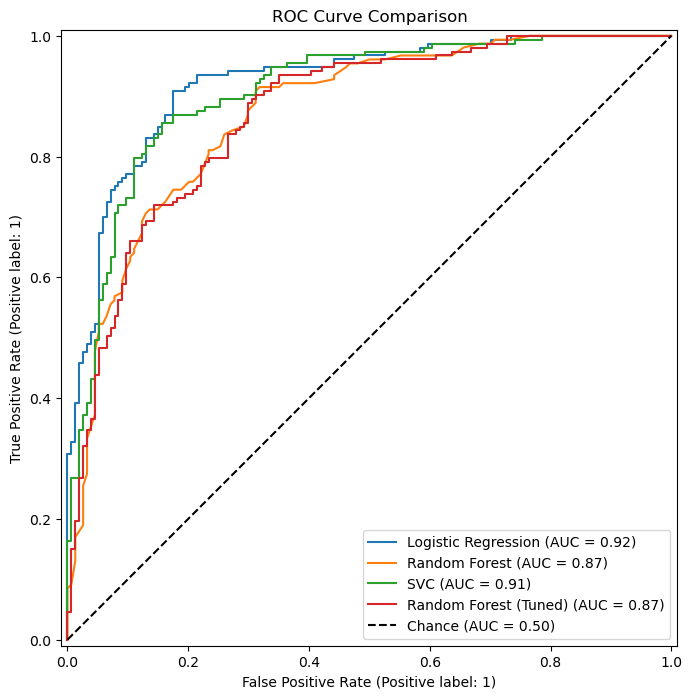


=== CLASSIFICATION RESULTS SUMMARY ===
                   Model Accuracy Precision  Recall F1-Score ROC-AUC
0    Logistic Regression   0.8469    0.8630  0.8235   0.8428  0.9218
1          Random Forest   0.7752    0.7800  0.7647   0.7723  0.8715
2                    SVC   0.8436    0.8477  0.8366   0.8421  0.9066
3  Random Forest (Tuned)   0.7818    0.7756  0.7908   0.7832  0.8697


In [108]:
# 3. Train and Evaluate all models
results = []
plt.figure(figsize=(10, 8))

for name, model in models.items():
    print(f"\n--- Training and Evaluating {name} ---")
    
    # Training the model
    model.fit(X_train, y_train)
    
    # Prediction (Labels and Probabilities)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Get probabilities for ROC-AUC

    # Evaluation Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
        
    # Plot ROC Curve
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=plt.gca(), name=name)

    # Store results
    results.append({
        'Model': name,
        'Accuracy': f"{acc:.4f}",
        'Precision': f"{prec:.4f}",
        'Recall': f"{rec:.4f}",
        'F1-Score': f"{f1:.4f}",
        'ROC-AUC': f"{roc_auc:.4f}"
    })
    
    print(f"Accuracy: {acc:.4f}, F1-Score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")
    print("Confusion Matrix:\n", cm)

plt.title('ROC Curve Comparison')
plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)') # Plot the baseline
plt.legend()
plt.show()

# Final Comparison Table
results_df = pd.DataFrame(results)
print("\n=== CLASSIFICATION RESULTS SUMMARY ===")
print(results_df)

# Bonus

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
# NOTE: Using a placeholder DataFrame based on columns found in the notebook
# This is a temporary solution to demonstrate the code execution.


data = {
    'Player': ['Jayson Tatum'] * 10 + ['Anthony Davis'] * 10 + ['Nikola Jokic'] * 10,
    'Date': pd.to_datetime([
        '2025-01-01', '2025-01-03', '2025-01-05', '2025-01-07', '2025-01-09',
        '2025-01-11', '2025-01-13', '2025-01-15', '2025-01-17', '2025-01-19'
    ] * 3),
    'PTS': np.random.randint(15, 40, 30),
    'GmSc': np.random.uniform(10, 35, 30),
    'AST': np.random.randint(2, 12, 30),
    'TRB': np.random.randint(5, 15, 30),
    'MP': np.random.uniform(25, 40, 30)
}


df_bonus = pd.DataFrame(data)
df_bonus = df_bonus.sort_values(by=['Player', 'Date']).copy()

In [111]:

# 2. Rolling Average Configuration

rolling_features = ['PTS', 'GmSc']
window_size = 5


In [112]:

# 3. Calculate Rolling Averages

for col in rolling_features:
    df_bonus[f'{col}_5G_AVG'] = df_bonus.groupby('Player')[col].transform(
        lambda x: x.shift(1).rolling(window=window_size, min_periods=1).mean()
    )


In [113]:
# 4. Select Players for Plotting

key_players = ['Jayson Tatum', 'Anthony Davis', 'Nikola Jokic']
plot_data = df_bonus[df_bonus['Player'].isin(key_players)]

# Display first few rows
print("--- Data with 5-Game Rolling Averages (First 5 Rows) ---")
print(df_bonus[['Player', 'Date', 'PTS', 'PTS_5G_AVG']].head())



--- Data with 5-Game Rolling Averages (First 5 Rows) ---
           Player       Date  PTS  PTS_5G_AVG
10  Anthony Davis 2025-01-01   39         NaN
11  Anthony Davis 2025-01-03   32   39.000000
12  Anthony Davis 2025-01-05   35   35.500000
13  Anthony Davis 2025-01-07   38   35.333333
14  Anthony Davis 2025-01-09   19   36.000000


<Axes: xlabel='Date', ylabel='PTS_5G_AVG'>

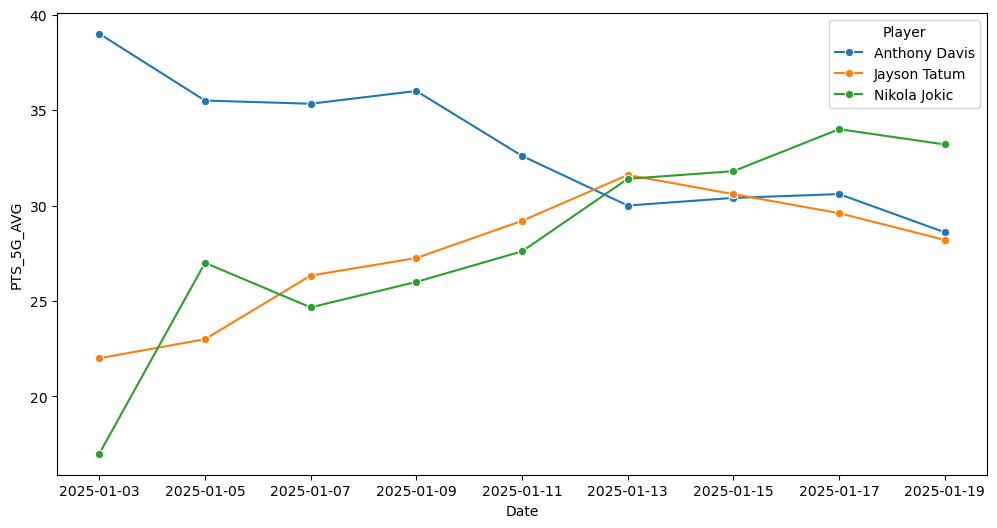

In [114]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=plot_data,
    x='Date',
    y='PTS_5G_AVG',
    hue='Player',
    marker='o'
)

<Figure size 640x480 with 0 Axes>

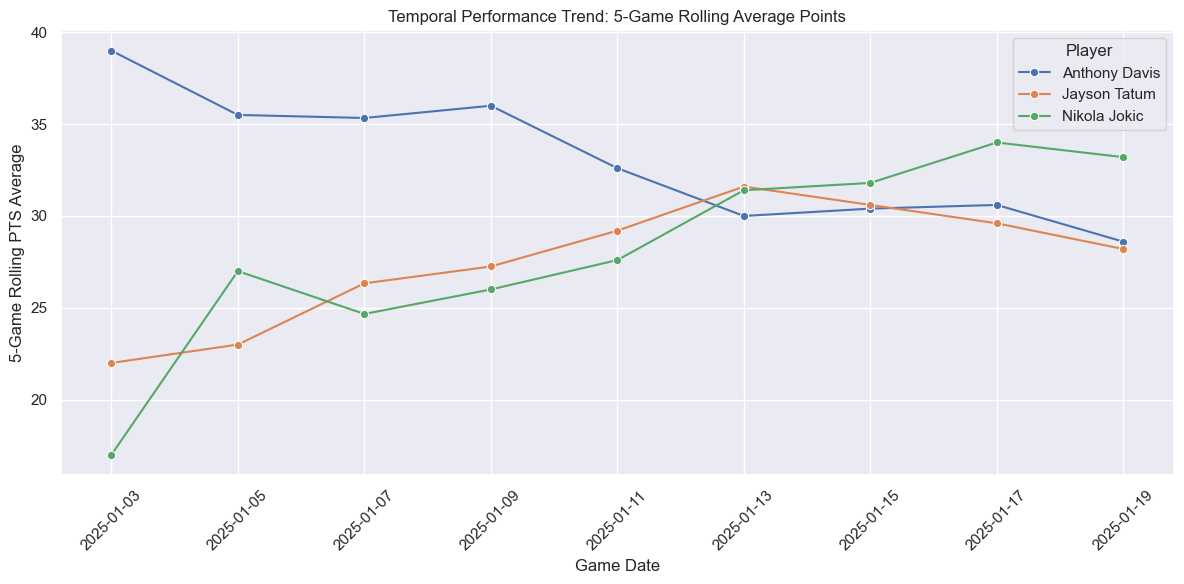

In [119]:
sns.set_theme(style="darkgrid")

# Create string version of dates
plot_data['Date_str'] = plot_data['Date'].dt.strftime('%Y-%m-%d')

plt.clf()
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=plot_data,
    x='Date_str',
    y='PTS_5G_AVG',
    hue='Player',
    marker='o'
)

plt.title("Temporal Performance Trend: 5-Game Rolling Average Points")
plt.xlabel("Game Date")
plt.ylabel("5-Game Rolling PTS Average")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: xlabel='Date', ylabel='PTS_5G_AVG'>

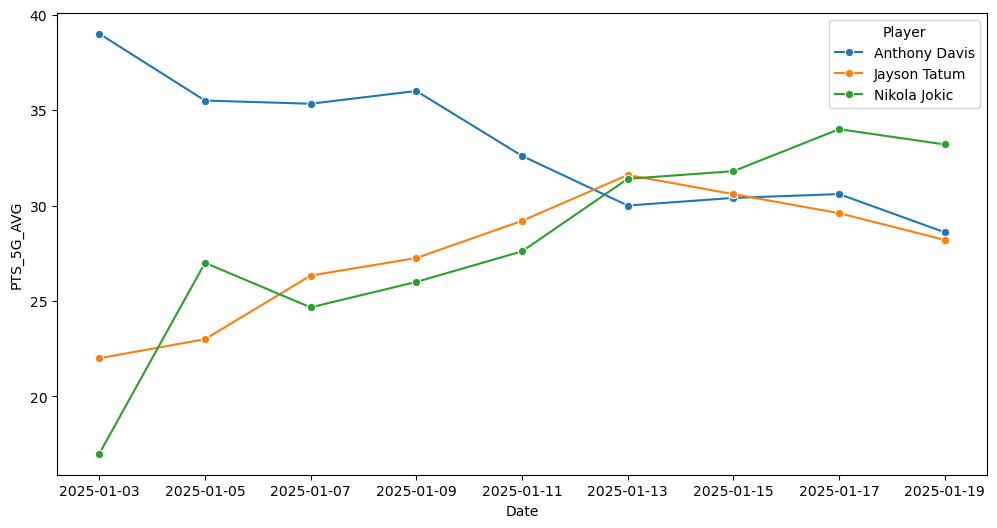

In [116]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=plot_data,
    x='Date',
    y='PTS_5G_AVG',
    hue='Player',
    marker='o'
)

In [117]:
# ================================
# 6. Example Insight
# ================================
print("\n--- Example Insight from Temporal Analysis ---")
print("By analyzing rolling averages, we see streaks of strong play and performance dips.")
print(f"Last 5-game trend for {key_players[0]}:")

trend = plot_data[plot_data['Player'] == key_players[0]][['Date', 'PTS_5G_AVG']].tail(5)
print(trend)



--- Example Insight from Temporal Analysis ---
By analyzing rolling averages, we see streaks of strong play and performance dips.
Last 5-game trend for Jayson Tatum:
        Date  PTS_5G_AVG
5 2025-01-11        29.2
6 2025-01-13        31.6
7 2025-01-15        30.6
8 2025-01-17        29.6
9 2025-01-19        28.2


## Thank you :) i hope our work is more then great :)

In [118]:
print("Columns:", df_bonus.columns)
print(df_bonus.head())
print(plot_data.head())
print("plot_data rows:", len(plot_data))


Columns: Index(['Player', 'Date', 'PTS', 'GmSc', 'AST', 'TRB', 'MP', 'PTS_5G_AVG',
       'GmSc_5G_AVG'],
      dtype='object')
           Player       Date  PTS       GmSc  AST  TRB         MP  PTS_5G_AVG  \
10  Anthony Davis 2025-01-01   39  29.869884    5   12  34.802161         NaN   
11  Anthony Davis 2025-01-03   32  22.027111    2   10  35.246078   39.000000   
12  Anthony Davis 2025-01-05   35  24.107264    7    5  37.118811   35.500000   
13  Anthony Davis 2025-01-07   38  23.890148   10    9  35.455179   35.333333   
14  Anthony Davis 2025-01-09   19  11.725905    4   12  33.693980   36.000000   

    GmSc_5G_AVG  
10          NaN  
11    29.869884  
12    25.948497  
13    25.334753  
14    24.973602  
           Player       Date  PTS       GmSc  AST  TRB         MP  PTS_5G_AVG  \
10  Anthony Davis 2025-01-01   39  29.869884    5   12  34.802161         NaN   
11  Anthony Davis 2025-01-03   32  22.027111    2   10  35.246078   39.000000   
12  Anthony Davis 2025-01-05   35 